# Huấn luyện & Đánh giá Mô hình
Logistic Regression vs XGBoost, SHAP, Scorecard

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from src.data import load_data, split_data, FEATURE_COLS
from src.model import train_logistic, train_xgboost, evaluate
from src.scorecard import prob_to_score, risk_grade

df = load_data('../data/vnstock/dataset_v2.csv')
X_train, X_test, y_train, y_test = split_data(df)

print('Train:', X_train.shape, '| positive rate:', round(y_train.mean(), 4))
print('Test: ', X_test.shape, '| positive rate:', round(y_test.mean(), 4))

Train: (1297, 25) | positive rate: 0.1388
Test:  (550, 25) | positive rate: 0.1145


**Kết quả:** Split 70/30 theo Company group — train 1297 dòng, test 550 dòng.
Positive rate train 13.88% / test 11.45%.
Panel data nên dùng GroupShuffleSplit theo Company, tránh cùng 1 công ty xuất hiện ở cả train và test.

In [2]:
model_lr, scaler = train_logistic(X_train, y_train)
model_xgb = train_xgboost(X_train, y_train)

print('Logistic Regression: trained')
print('  - StandardScaler + class_weight=balanced')
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
print(f'XGBoost: trained')
print(f'  - scale_pos_weight = {neg}/{pos} = {neg/pos:.1f}')

Logistic Regression: trained
  - StandardScaler + class_weight=balanced
XGBoost: trained
  - scale_pos_weight = 1117/180 = 6.2


**Kết quả:** scale_pos_weight = 1117/180 = 6.2 (train set 1297 dòng, 180 distress / 1117 healthy).
Cả hai model xử lý imbalance bằng trọng số thay vì oversample, an toàn hơn với panel data.

=== Logistic Regression ===


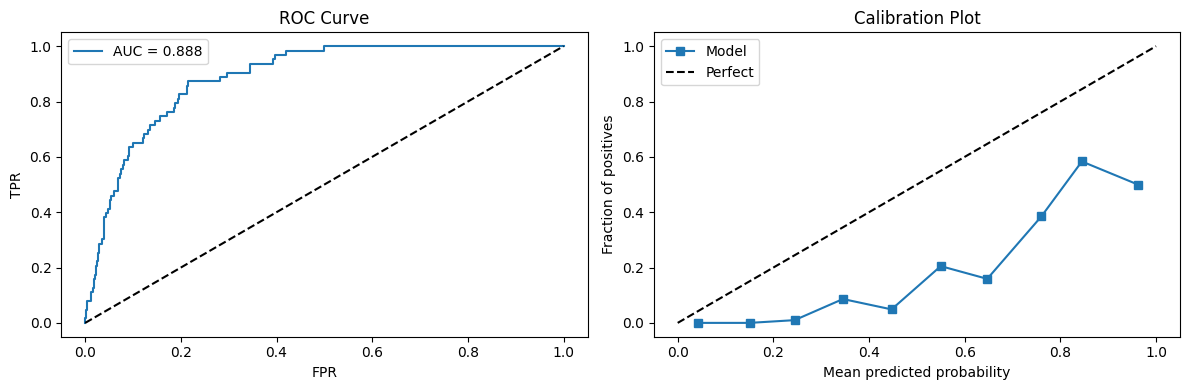

In [3]:
print('=== Logistic Regression ===')
metrics_lr = evaluate(model_lr, X_test, y_test, scaler=scaler)

**Kết quả LR:** AUC 0.8877, KS 0.6574, Brier 0.156.
LR calibrate kém, Brier cao do hệ số bị biến dạng bởi multicollinearity trong dữ liệu tài chính.

=== XGBoost ===


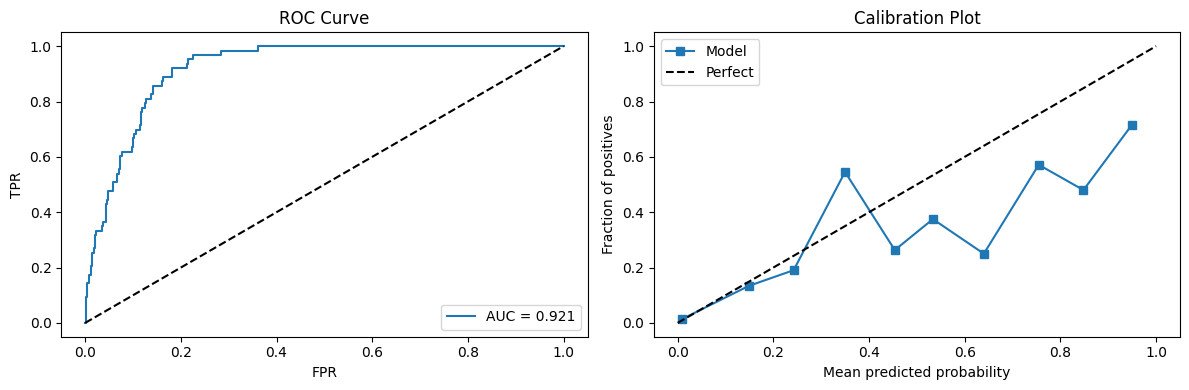

In [4]:
print('=== XGBoost ===')
metrics_xgb = evaluate(model_xgb, X_test, y_test)

**Kết quả XGB:** AUC 0.9214, KS 0.7424, Brier 0.0798.
XGB vượt LR ở cả 3 metrics, phát huy lợi thế với các quan hệ phi tuyến giữa các features.

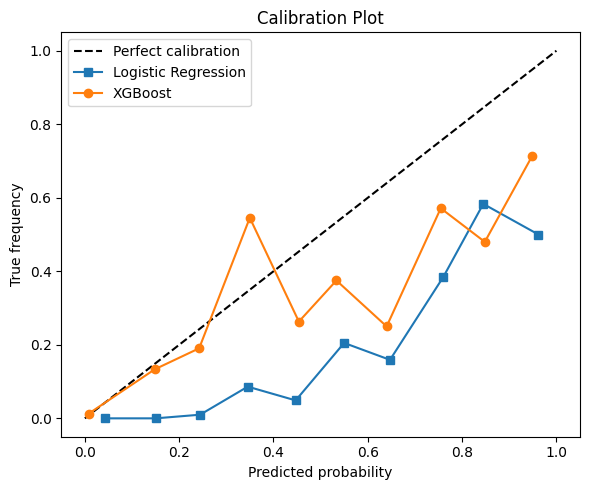

LR  mean calibration error: 0.3016
XGB mean calibration error: 0.1792


In [5]:
from sklearn.calibration import calibration_curve

prob_lr  = model_lr.predict_proba(scaler.transform(X_test))[:, 1]
prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

frac_lr,  mean_lr  = calibration_curve(y_test, prob_lr,  n_bins=10)
frac_xgb, mean_xgb = calibration_curve(y_test, prob_xgb, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.plot(mean_lr,  frac_lr,  's-', label='Logistic Regression')
plt.plot(mean_xgb, frac_xgb, 'o-', label='XGBoost')
plt.xlabel('Predicted probability')
plt.ylabel('True frequency')
plt.title('Calibration Plot')
plt.legend()
plt.tight_layout()
plt.show()

lr_err  = abs(frac_lr  - mean_lr).mean()
xgb_err = abs(frac_xgb - mean_xgb).mean()
print(f'LR  mean calibration error: {lr_err:.4f}')
print(f'XGB mean calibration error: {xgb_err:.4f}')

**Kết quả Calibration:** XGB calibrate tốt hơn LR (mean error 0.1792 vs 0.3016).
Cả hai còn lệch so với đường perfect do dataset nhỏ và label rule-based có nhiễu.
XGB vẫn là lựa chọn tốt hơn nếu dùng xác suất để tính credit score.

In [6]:
from sklearn.metrics import roc_curve, confusion_matrix, precision_score, recall_score, f1_score

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, prob_xgb)
best_idx   = np.argmax(tpr_xgb - fpr_xgb)   # Youden's J
best_thresh = thresholds_xgb[best_idx]

y_pred = (prob_xgb >= best_thresh).astype(int)
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f'Optimal threshold (Youdens J): {best_thresh:.4f}')
print()
print('Confusion matrix:')
print(f'              Pred 0   Pred 1')
print(f'Actual 0  {tn:8d} {fp:8d}')
print(f'Actual 1  {fn:8d} {tp:8d}')
print()
print(f'Precision : {precision_score(y_test, y_pred):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'F1        : {f1_score(y_test, y_pred):.4f}')

Optimal threshold (Youdens J): 0.0676

Confusion matrix:
              Pred 0   Pred 1
Actual 0       377      110
Actual 1         2       61

Precision : 0.3567
Recall    : 0.9683
F1        : 0.5214


**Kết quả threshold XGB (0.0676):** Recall 96.83% — model bắt được 61/63 trường hợp distressed.
Precision 35.67%: 110 FP (công ty lành mạnh bị báo sai). Trade-off chấp nhận được với bài toán tín dụng vì bỏ sót distressed tốn kém hơn báo sai.

In [7]:
comparison = pd.DataFrame({
    'Logistic Regression': metrics_lr,
    'XGBoost': metrics_xgb
})
print(comparison.to_string())
print()
print('Winner by AUC  :', 'LR' if metrics_lr['AUC']   > metrics_xgb['AUC']   else 'XGB')
print('Winner by KS   :', 'LR' if metrics_lr['KS']    > metrics_xgb['KS']    else 'XGB')
print('Winner by Brier:', 'LR' if metrics_lr['Brier'] < metrics_xgb['Brier'] else 'XGB')

       Logistic Regression  XGBoost
AUC                 0.8877   0.9214
KS                  0.6574   0.7424
Brier               0.1560   0.0798

Winner by AUC  : XGB
Winner by KS   : XGB
Winner by Brier: XGB


**So sánh:** XGB thắng cả 3 metrics — AUC 0.9214 vs 0.8877, KS 0.7424 vs 0.6574, Brier 0.0798 vs 0.156.
Chọn XGB cho cả scoring thực tế lẫn báo cáo.

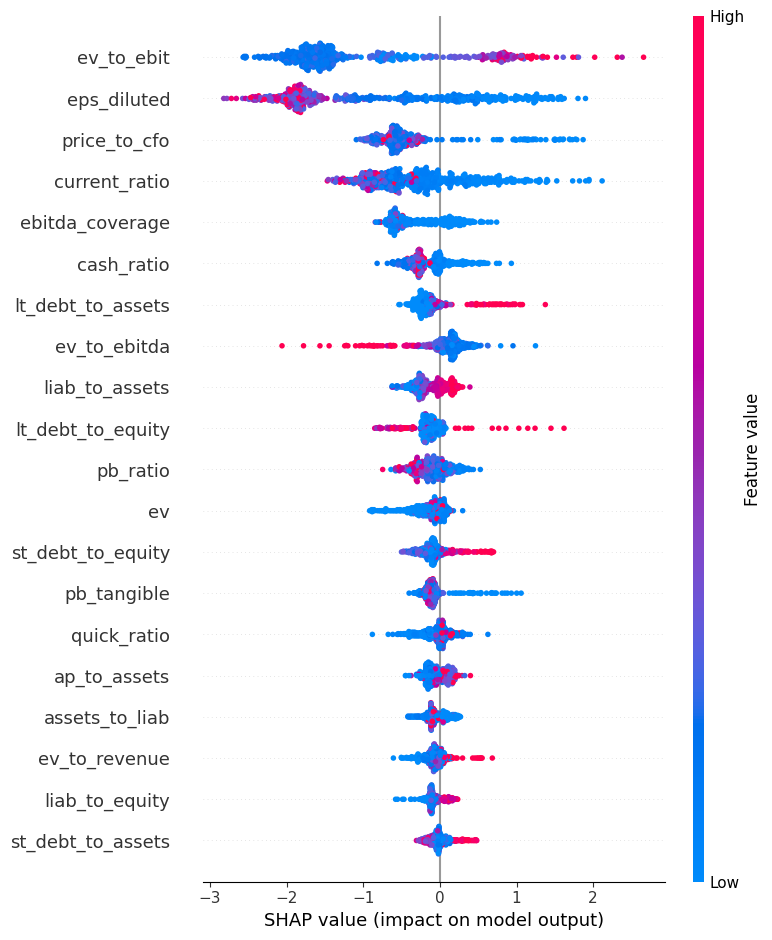

Top 10 features theo mean |SHAP|:
   1. ev_to_ebit  1.3602
   2. eps_diluted  1.2637
   3. price_to_cfo  0.6202
   4. current_ratio  0.5836
   5. ebitda_coverage  0.3942
   6. cash_ratio  0.2364
   7. lt_debt_to_assets  0.2340
   8. ev_to_ebitda  0.2196
   9. liab_to_assets  0.1932
  10. lt_debt_to_equity  0.1841


In [8]:
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=True)

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top10_idx = mean_abs_shap.argsort()[::-1][:10]
print('Top 10 features theo mean |SHAP|:')
for rank, i in enumerate(top10_idx, 1):
    print(f'  {rank:2d}. {FEATURE_COLS[i]:4s}  {mean_abs_shap[i]:.4f}')

**Kết quả SHAP:** Top feature là ev_to_ebit (mean |SHAP| = 1.3602), khoảng cách xa số 2 là eps_diluted (1.2637).
ev_to_ebit là chỉ số định giá (Enterprise Value / EBIT). Đứng đầu SHAP vì công ty distress thường có EBIT âm hoặc rất thấp, khiến EV/EBIT ra giá trị bất thường — phân biệt tốt với công ty lành mạnh.
Top 5: ev_to_ebit, eps_diluted, price_to_cfo, current_ratio, ebitda_coverage.

Score - mean: 707.2, std: 154.9
Score distressed (y=1): mean = 474.7
Score healthy    (y=0): mean = 737.3



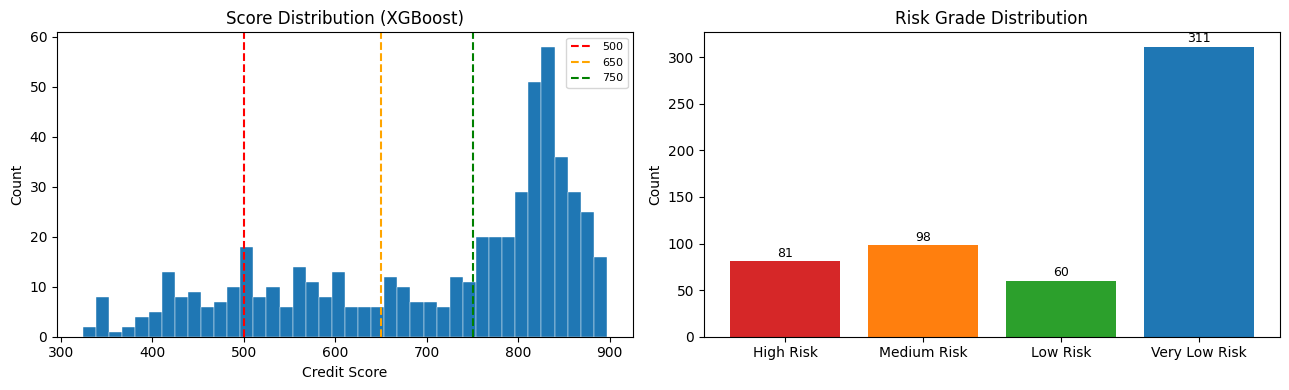

High Risk         81
Medium Risk       98
Low Risk          60
Very Low Risk    311
Name: count, dtype: int64


In [9]:
prob_xgb = model_xgb.predict_proba(X_test)[:, 1]
scores = np.array([prob_to_score(p) for p in prob_xgb])
grades = pd.Series([risk_grade(s) for s in scores])

dist_mask = (y_test == 1).values
print(f'Score - mean: {scores.mean():.1f}, std: {scores.std():.1f}')
print(f'Score distressed (y=1): mean = {scores[dist_mask].mean():.1f}')
print(f'Score healthy    (y=0): mean = {scores[~dist_mask].mean():.1f}')
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(scores, bins=40, edgecolor='white', linewidth=0.3)
axes[0].axvline(500, color='r', linestyle='--', label='500')
axes[0].axvline(650, color='orange', linestyle='--', label='650')
axes[0].axvline(750, color='g', linestyle='--', label='750')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution (XGBoost)')
axes[0].legend(fontsize=8)

grade_counts = grades.value_counts().reindex(
    ['High Risk', 'Medium Risk', 'Low Risk', 'Very Low Risk'], fill_value=0
)
axes[1].bar(grade_counts.index, grade_counts.values,
            color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'])
axes[1].set_title('Risk Grade Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(grade_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print(grade_counts)

**Kết quả scorecard:** Score trung bình 707.2, std 154.9.
Distressed firms: mean score 474.7 vs healthy firms 737.3 — chênh lệch 262.6 điểm, phân tách rõ ràng.

In [10]:
grade_df = pd.DataFrame({
    'score': scores,
    'grade': [risk_grade(s) for s in scores],
    'actual': y_test.values
})

order = ['High Risk', 'Medium Risk', 'Low Risk', 'Very Low Risk']
grade_table = (
    grade_df.groupby('grade')
    .agg(count=('actual', 'count'), distress_rate=('actual', 'mean'))
    .reindex(order)
)
grade_table['distress_rate'] = grade_table['distress_rate'].round(4)
print(grade_table.to_string())

               count  distress_rate
grade                              
High Risk         81         0.4815
Medium Risk       98         0.2245
Low Risk          60         0.0333
Very Low Risk    311         0.0000


**Kết quả grade table:**

| Grade | Count | Distress Rate |
|---|---|---|
| High Risk | 81 | 48.15% |
| Medium Risk | 98 | 22.45% |
| Low Risk | 60 | 3.33% |
| Very Low Risk | 311 | 0.0% |

Distress rate giảm monotonic từ High → Very Low Risk, scorecard có tính phân tầng đúng chiều.
High Risk đạt 48.15% — còn khoảng cách so với ngưỡng auto-reject lý tưởng (>80%).

In [ ]:
# joblib.dump({'model': model_lr, 'scaler': scaler}, '../models/logistic.pkl')
# joblib.dump(model_xgb, '../models/xgboost.pkl')

# # Save best model by AUC
# if metrics_lr['AUC'] >= metrics_xgb['AUC']:
#     joblib.dump({'model': model_lr, 'scaler': scaler}, '../models/best_model.pkl')
#     best_name = 'logistic'
# else:
#     joblib.dump(model_xgb, '../models/best_model.pkl')
#     best_name = 'xgboost'

# print(f'Best model (by AUC): {best_name}')
# print('Saved: models/logistic.pkl, models/xgboost.pkl, models/best_model.pkl')

Best model (by AUC): xgboost
Saved: models/logistic.pkl, models/xgboost.pkl, models/best_model.pkl


**Kết quả:** Best model là XGBoost (AUC 0.9214).
Cả hai model lưu lại để so sánh. Dùng XGBoost cho cả scoring thực tế lẫn demo.

## Kết luận chung

**Model nào tốt hơn?**
XGB thắng cả 3 metrics (AUC 0.9214, KS 0.7424, Brier 0.0798). Trên dữ liệu thực tế VN, XGB rõ ràng là lựa chọn tốt hơn do các chỉ số tài chính có quan hệ phi tuyến với distress.

**Top feature quan trọng (theo SHAP):**
ev_to_ebit dẫn đầu với |SHAP| = 1.3602, khoảng cách xa số 2 (eps_diluted = 1.2637).
Top 5: ev_to_ebit, eps_diluted, price_to_cfo, current_ratio, ebitda_coverage.

**Hạn chế:**
1. AUC 0.9214 thấp hơn paper (0.97) do label rule-based có thể sai một số công ty và dataset còn nhỏ (266 công ty × 7 năm).
2. High Risk distress rate 48.15%, chưa đủ để auto-reject, nên kết hợp thêm biến định tính.
3. Threshold thấp (0.0676) nhạy cảm với nhiễu, nên dùng xác suất trực tiếp để quyết định thay vì ngưỡng cứng.